# Importing Libraries 

In [2]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, log_loss, roc_auc_score

# Load datasets

In [3]:
train_df = pd.read_csv('dg_incident_train.csv')
val_df = pd.read_csv('dg_incident_validation.csv')
test_df = pd.read_csv('dg_incident_test.csv')

In [4]:
print(train_df.head())

   record_id            timestamp shc_code origin_destination  dg_class  \
0  DG_000001  2025-11-04 07:53:23      RFL            AMS-JED       4.0   
1  DG_000002  2025-04-13 05:40:50      MAG            MXP-JED       2.1   
2  DG_000003  2025-03-10 17:07:01      CAO            AMS-JED       2.1   
3  DG_000004  2025-06-15 19:27:32      ELI            OSL-JED       8.0   
4  DG_000005  2025-06-04 02:33:27      ELI            AMS-JED       2.1   

  packaging_type  handling_error_count  previous_incident_count  \
0        Plastic                     2                        3   
1          Fiber                     4                        1   
2          Metal                     4                        1   
3          Fiber                     4                        6   
4        Plastic                     5                        2   

   cargo_weight_kg  temperature_celsius  humidity_percentage  \
0         36366.21                35.58                36.94   
1         38195.46

# data cleaning and feature engineering

In [5]:
# --- PHASE 1: DATA CLEANING ---
def clean_data(df):
    # Make a copy to avoid changing the original raw data
    df_clean = df.copy()
    
    # 1. Handle Missing Values
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            if df_clean[col].dtype == 'object' or df_clean[col].dtype.name == 'category':
                # Filling categorical with mode
                df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
            else:
                # Filling numerical with median
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    
    # 2. Format Timestamps & Feature Expansion
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
    df_clean['shipment_hour'] = df_clean['timestamp'].dt.hour
    df_clean['shipment_day_of_week'] = df_clean['timestamp'].dt.dayofweek # New: Captures weekend risk
    df_clean['shipment_month'] = df_clean['timestamp'].dt.month
    
    # 3. Type Casting for CatBoost
    # CatBoost requires categorical columns to be explicitly strings or categories
    cat_cols = ['shc_code', 'origin_destination', 'packaging_type', 'weather_condition']
    for col in cat_cols:
        df_clean[col] = df_clean[col].astype(str)
    
    # 4. Remove "Noise" 
    # record_id and shipper_id are dropped. timestamp is dropped AFTER extraction.
    noise_cols = ['record_id', 'shipper_id', 'timestamp']
    df_clean = df_clean.drop(columns=noise_cols)
    
    return df_clean

# Apply cleaning
train_cleaned = clean_data(train_df)
val_cleaned = clean_data(val_df)
test_cleaned = clean_data(test_df)

print("Cleaning Complete for CatBoost.")

Cleaning Complete for CatBoost.


In [6]:
train_cleaned.head()

,shc_code,origin_destination,dg_class,packaging_type,handling_error_count,previous_incident_count,cargo_weight_kg,temperature_celsius,humidity_percentage,weather_condition,safety_staff_count,doc_audit_result,incident_flag,shipment_hour,shipment_day_of_week,shipment_month
0,RFL,AMS-JED,4.0,Plastic,2,3,36366.21,35.58,36.94,Extreme Heat,31,1,0,7,1,11
1,MAG,MXP-JED,2.1,Fiber,4,1,38195.46,41.83,10.03,Fog,29,0,0,5,6,4
2,CAO,AMS-JED,2.1,Metal,4,1,40098.77,15.72,38.36,Storm,7,1,1,17,0,3
3,ELI,OSL-JED,8.0,Fiber,4,6,3589.44,-11.79,15.58,Rain,1,0,0,19,6,6
4,ELI,AMS-JED,2.1,Plastic,5,2,32940.57,10.63,67.59,Clear,47,0,1,2,2,6


In [7]:
# --- PHASE 1: FEATURE ENGINEERING ---

def engineer_features(df):
    df_eng = df.copy()
    
    # 1. Mishandling Threshold
    df_eng['is_critical_mishandling'] = (df_eng['handling_error_count'] > 7).astype(int)
    
    # 2. Climate Shock Risk (OSL-JED + Temperature)
    # Captures the thermal expansion risk for specific route and high temperature
    df_eng['climate_shock_risk'] = (
        (df_eng['origin_destination'] == 'OSL-JED') & 
        (df_eng['temperature_celsius'] > 30)
    ).astype(int)
    
    # 3. Trusted Shipper Status
    # High frequency of past violations marks an untrusted shipper
    df_eng['is_untrusted_shipper'] = (df_eng['previous_incident_count'] > 5).astype(int)
    
    return df_eng

# Apply to your cleaned dataframes
train_final = engineer_features(train_cleaned)
val_final = engineer_features(val_cleaned)
test_final = engineer_features(test_cleaned)

print("Feature Engineering Complete.")
print(f"New Features Added: is_critical_mishandling, climate_shock_risk, is_untrusted_shipper")

Feature Engineering Complete.
New Features Added: is_critical_mishandling, climate_shock_risk, is_untrusted_shipper


In [8]:
train_final.head()

,shc_code,origin_destination,dg_class,packaging_type,handling_error_count,previous_incident_count,cargo_weight_kg,temperature_celsius,humidity_percentage,weather_condition,safety_staff_count,doc_audit_result,incident_flag,shipment_hour,shipment_day_of_week,shipment_month,is_critical_mishandling,climate_shock_risk,is_untrusted_shipper
0,RFL,AMS-JED,4.0,Plastic,2,3,36366.21,35.58,36.94,Extreme Heat,31,1,0,7,1,11,0,0,0
1,MAG,MXP-JED,2.1,Fiber,4,1,38195.46,41.83,10.03,Fog,29,0,0,5,6,4,0,0,0
2,CAO,AMS-JED,2.1,Metal,4,1,40098.77,15.72,38.36,Storm,7,1,1,17,0,3,0,0,0
3,ELI,OSL-JED,8.0,Fiber,4,6,3589.44,-11.79,15.58,Rain,1,0,0,19,6,6,0,0,1
4,ELI,AMS-JED,2.1,Plastic,5,2,32940.57,10.63,67.59,Clear,47,0,1,2,2,6,0,0,0


# Data Encoding

In [9]:
# --- PHASE 1: DATA FINALIZATION ---

def finalize_phase_1(df):
    df_final = df.copy()
    
    # --- 1. PATTERN LOGIC: THE "DANGEROUS COMBINATIONS" ---
    
    # Combination: Physical Abuse + High Hazard (Class 2.1 is Flammable Gas)
    df_final['gas_handling_risk'] = ((df_final['dg_class'] == 2.1) & 
                                     (df_final['handling_error_count'] > 5)).astype(int)
    
    # Combination: Climate Shock
    df_final['thermal_expansion_risk'] = ((df_final['origin_destination'] == 'OSL-JED') & 
                                          (df_final['temperature_celsius'] > 35) & 
                                          (df_final['dg_class'] == 3.0)).astype(int)

    # Combination: Untrusted Shipper + High Hazard SHC
    df_final['shipper_hazard_combo'] = ((df_final['previous_incident_count'] > 5) & 
                                        (df_final['shc_code'] == 'CAO')).astype(int)

    # --- 2. TYPE CASTING FOR CATBOOST ---
    # Instead of Encoding, we ensure all categorical features are 'string' or 'object'
    # CatBoost will perform its own 'Ordered Boosting' encoding internally.
    categorical_cols = ['shc_code', 'origin_destination', 'packaging_type', 'weather_condition']
    
    for col in categorical_cols:
        df_final[col] = df_final[col].fillna('Unknown').astype(str)
        
    return df_final

# Apply to your current dataframes
train_ready = finalize_phase_1(train_final)
val_ready = finalize_phase_1(val_final)
test_ready = finalize_phase_1(test_final)

print("Phase 1 Successfully Completed for CatBoost!")
print(f"Total Features for the Model: {train_ready.shape[1] - 1}")

Phase 1 Successfully Completed for CatBoost!
Total Features for the Model: 21


# Exploratory Data Analysis

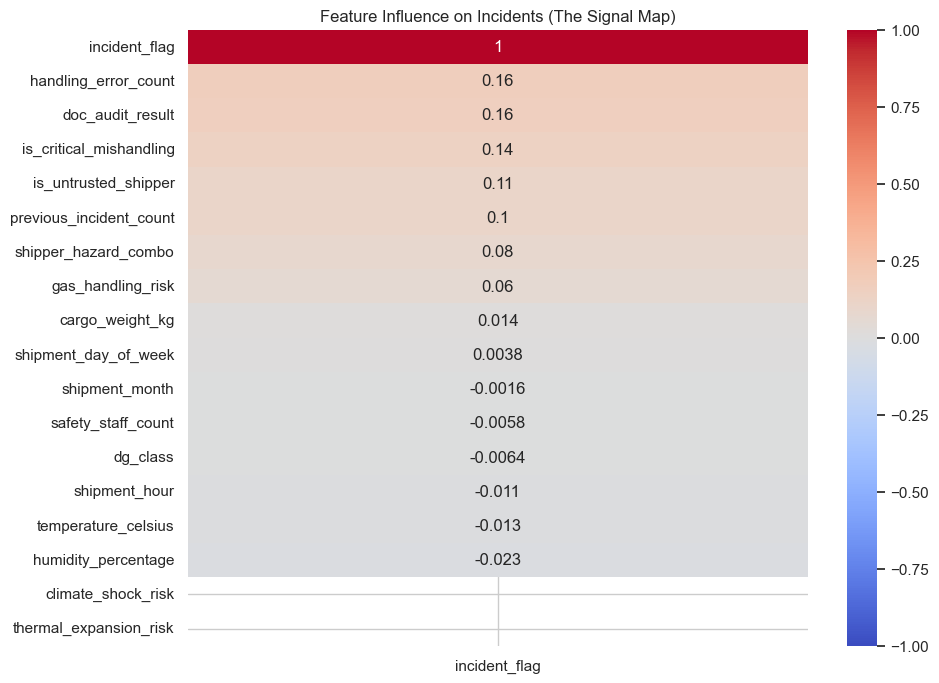

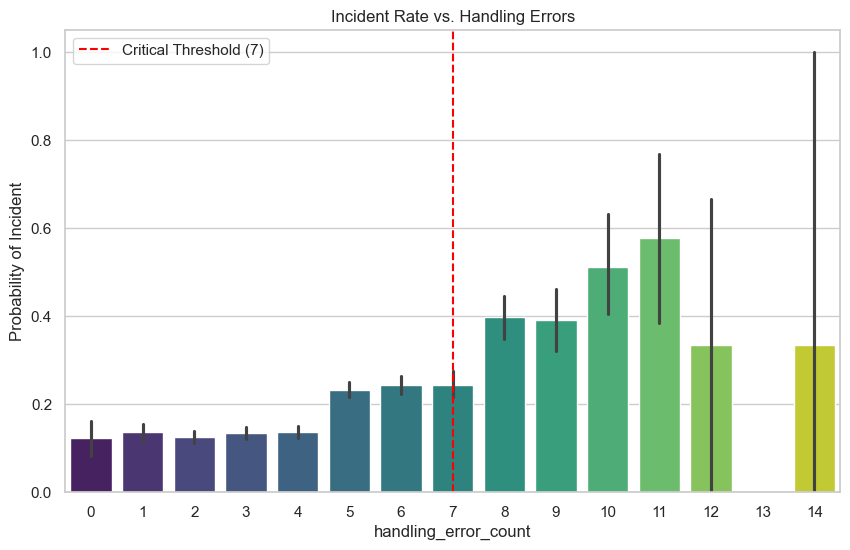

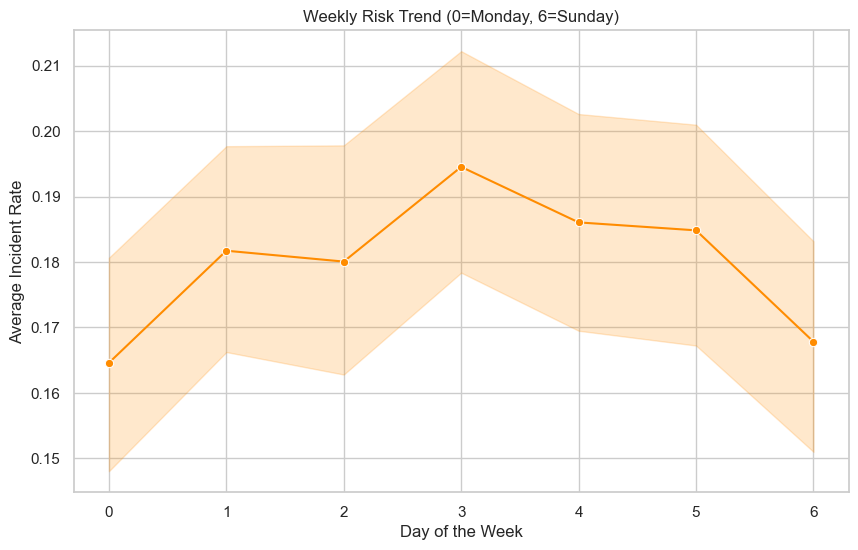

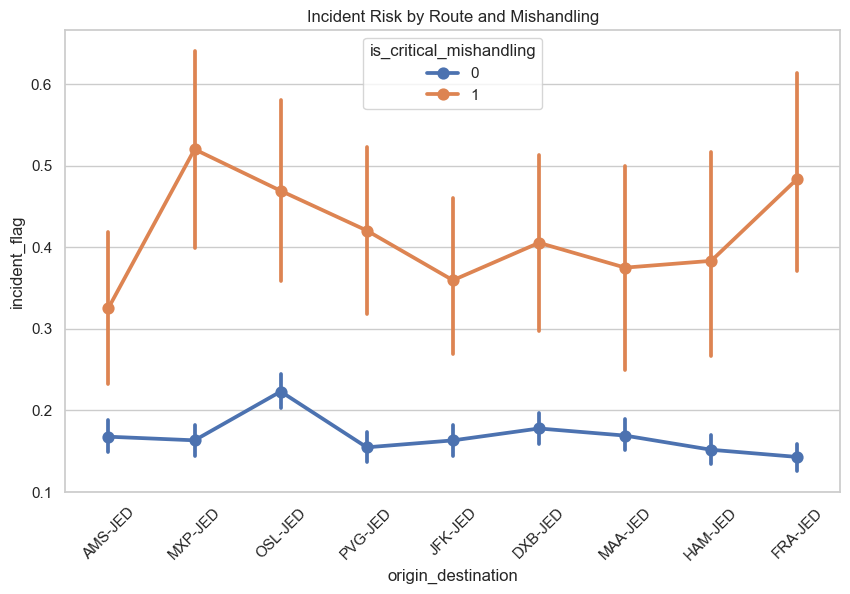

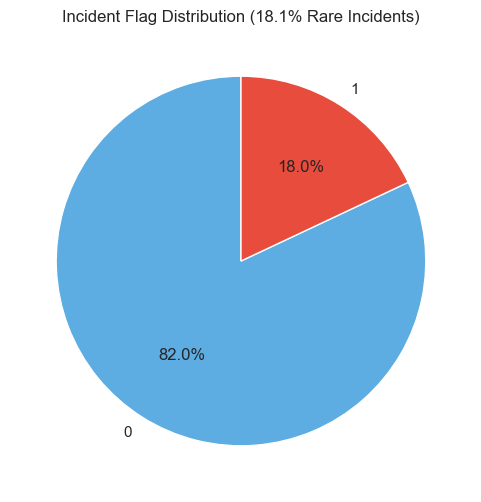

In [10]:
# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# 1. THE CORRELATION HEATMAP
# Using numeric_only=True because we kept categorical columns as raw strings for CatBoost
plt.figure(figsize=(10, 8))
corr_matrix = train_ready.corr(numeric_only=True)
sns.heatmap(corr_matrix[['incident_flag']].sort_values(by='incident_flag', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Influence on Incidents (The Signal Map)")
plt.show()

# 2. THE "PHYSICAL BREAKPOINT" ANALYSIS
# Validating if the risk jumps after 7 errors as per our 'is_critical_mishandling' logic
plt.figure(figsize=(10, 6))
sns.barplot(x='handling_error_count', y='incident_flag', data=train_ready, palette='viridis')
plt.axvline(x=7, color='red', linestyle='--', label='Critical Threshold (7)')
plt.title("Incident Rate vs. Handling Errors")
plt.ylabel("Probability of Incident")
plt.legend()
plt.show()

# 3. TEMPORAL RISK ANALYSIS (New Feature: Day of Week)
# Visualizing if certain days carry higher risk scores
plt.figure(figsize=(10, 6))
sns.lineplot(x='shipment_day_of_week', y='incident_flag', data=train_ready, marker='o', color='darkorange')
plt.title("Weekly Risk Trend (0=Monday, 6=Sunday)")
plt.ylabel("Average Incident Rate")
plt.xlabel("Day of the Week")
plt.show()

# 4. CLIMATE SHOCK & ROUTE ANALYSIS
# Checking how the OSL-JED route interacts with mishandling
plt.figure(figsize=(10, 6))
sns.pointplot(x='origin_destination', y='incident_flag', hue='is_critical_mishandling', data=train_ready)
plt.title("Incident Risk by Route and Mishandling")
plt.xticks(rotation=45)
plt.show()

# 5. CLASS DISTRIBUTION (Target Imbalance Check)
plt.figure(figsize=(6, 6))
train_ready['incident_flag'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#5DADE2', '#E74C3C'], startangle=90)
plt.title("Incident Flag Distribution (18.1% Rare Incidents)")
plt.ylabel("")
plt.show()

In [11]:
# --- PHASE 2: SELECTION & PRIORITY-BASED TRAINING ---
from catboost import CatBoostRegressor # Changed to Regressor for risk magnitude
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. PREPARE X (Features) AND y (Target)
X_train = train_ready.drop(columns=['incident_flag' ,'shipment_hour', 'shipment_day_of_week', 'shipment_month']) # Dropping temporal features for this model
y_train = train_ready['incident_flag']

X_val = val_ready.drop(columns=['incident_flag', 'shipment_hour', 'shipment_day_of_week', 'shipment_month'])
y_val = val_ready['incident_flag']

X_test = test_ready.drop(columns=['incident_flag', 'shipment_hour', 'shipment_day_of_week', 'shipment_month'])
y_test = test_ready['incident_flag']

# 2. IDENTIFY CATEGORICAL FEATURES
cat_features_list = ['shc_code', 'origin_destination', 'packaging_type', 'weather_condition']

# 3. MODEL SELECTION: CatBoostRegressor
# To fix the error, we use 'RMSE' as BOTH the loss and the metric.
# Note: Regressors use 'loss_function' instead of 'scale_pos_weight'.
baseline_model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=4, 
    loss_function='RMSE', # Aligning loss with the metric
    eval_metric='RMSE', 
    random_seed=42,
    verbose=False,
    border_count=32,
    l2_leaf_reg=3
)

# 4. TRAINING
print("Training the CatBoost Risk Magnitude model...")
baseline_model.fit(
    X_train, y_train,
    cat_features=cat_features_list,
    eval_set=(X_val, y_val),
    use_best_model=True
)

print("Phase 2 Training Complete.")

Training the CatBoost Risk Magnitude model...
Phase 2 Training Complete.


--- SAFETY-FIRST PERFORMANCE REPORT (REGRESSION AUDIT) ---
Mean Squared Error (MSE): 0.1320
Root Mean Squared Error (RMSE): 0.3633
Mean Absolute Error (MAE): 0.2674
R2 Score (Variance Explained): 0.1057
Log Loss (Probabilistic Penalty): 0.4175
Ranking AUC (Score Separation): 0.7401


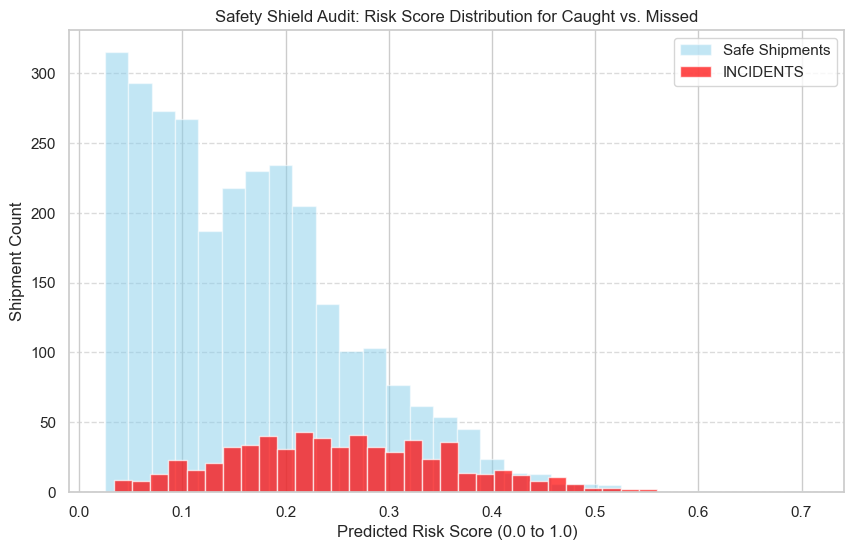

In [12]:
# --- PHASE 3: SAFETY-FIRST EVALUATION (REGRESSION AUDIT) ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, log_loss, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# 1. GENERATE CONTINUOUS RISK SCORES
# Using the baseline_model (Regressor) to predict risk magnitude
test_risk_scores = baseline_model.predict(X_test)

# Clamping scores between 0 and 1 for calculation stability and logical reporting
test_risk_scores = np.clip(test_risk_scores, 0, 1)

# 2. CALCULATE REGRESSION PERFORMANCE METRICS
mse = mean_squared_error(y_test, test_risk_scores)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, test_risk_scores)
r2 = r2_score(y_test, test_risk_scores)

# 3. PRINT THE SAFETY REGRESSION REPORT
print("--- SAFETY-FIRST PERFORMANCE REPORT (REGRESSION AUDIT) ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R2 Score (Variance Explained): {r2:.4f}")
print(f"Log Loss (Probabilistic Penalty): {log_loss(y_test, test_risk_scores):.4f}")
print(f"Ranking AUC (Score Separation): {roc_auc_score(y_test, test_risk_scores):.4f}")

# 4. VISUALIZE THE "SAFETY SHIELD"
plt.figure(figsize=(10, 6))
plt.hist(test_risk_scores[y_test == 0], bins=30, alpha=0.5, label='Safe Shipments', color='skyblue')
plt.hist(test_risk_scores[y_test == 1], bins=30, alpha=0.7, label='INCIDENTS', color='red')
plt.title("Safety Shield Audit: Risk Score Distribution for Caught vs. Missed")
plt.xlabel("Predicted Risk Score (0.0 to 1.0)")
plt.ylabel("Shipment Count")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [13]:
# --- PHASE 4: TOP RISK AUDIT & REASON CODES ---

# 1. ATTACH RISK SCORES TO TEST DATA
# We use the risk scores generated in Phase 3 for the baseline_model
test_ready['predicted_risk_score'] = test_risk_scores

# 2. GENERATE THE TOP 5 PRIORITY INSPECTION LIST
# Ranking shipments by the magnitude of predicted risk (highest magnitude first)
top_5_priority = test_ready.sort_values(by='predicted_risk_score', ascending=False).head(5)

# 3. REASON CODE LOGIC FUNCTION (Parametric details analysis)
def generate_safety_audit(row):
    reasons = []
    
    # Primary Logic Drivers (Critical Priority)
    if row['handling_error_count'] > 7 or row['is_critical_mishandling'] == 1:
        reasons.append(f"CRITICAL MISHANDLING: High error count ({row['handling_error_count']}) detected.")
        
    if row['dg_class'] in [2.1, 3.0, 4.0]:
        reasons.append(f"VOLATILE COMMODITY: Class {row['dg_class']} has high hazard risk.")
    
    # Secondary Logic Drivers (High Priority)
    if row['climate_shock_risk'] == 1:
        reasons.append("CLIMATE SHOCK: Thermal expansion risk due to OSL-JED route and high temp.")
        
    if row['is_untrusted_shipper'] == 1:
        reasons.append("SHIPPER HISTORY: High frequency of past safety violations.")
    
    # Combination Risk Drivers (Phase 1 Finalization Logic)
    if row['gas_handling_risk'] == 1:
        reasons.append("COMPOUND RISK: Flammable gas mishandling detected.")
        
    return reasons if reasons else ["Systemic cumulative risk factors."]

# 4. PRINT THE OPERATIONAL AUDIT (Predicted Dangerous Percentage)
print("--- TOP 5 PRIORITY INSPECTION LIST (CATBOOST AUDIT) ---")
for idx, row in top_5_priority.iterrows():
    reasons = generate_safety_audit(row)
    # The more reason codes triggered, the higher the human intervention priority
    print(f"\nRANKING: #{len(reasons)} Priority Factors")
    print(f"SHIPMENT INDEX: {idx}")
    print(f"RISK SCORE (DANGEROUS PERCENTAGE): {row['predicted_risk_score']:.2%}")
    print("REASON CODES:")
    for r in reasons:
        print(f" - {r}")

--- TOP 5 PRIORITY INSPECTION LIST (CATBOOST AUDIT) ---

RANKING: #2 Priority Factors
SHIPMENT INDEX: 2314
RISK SCORE (DANGEROUS PERCENTAGE): 70.73%
REASON CODES:
 - CRITICAL MISHANDLING: High error count (11) detected.
 - SHIPPER HISTORY: High frequency of past safety violations.

RANKING: #1 Priority Factors
SHIPMENT INDEX: 3236
RISK SCORE (DANGEROUS PERCENTAGE): 59.60%
REASON CODES:
 - SHIPPER HISTORY: High frequency of past safety violations.

RANKING: #1 Priority Factors
SHIPMENT INDEX: 2972
RISK SCORE (DANGEROUS PERCENTAGE): 55.97%
REASON CODES:
 - SHIPPER HISTORY: High frequency of past safety violations.

RANKING: #1 Priority Factors
SHIPMENT INDEX: 2624
RISK SCORE (DANGEROUS PERCENTAGE): 55.94%
REASON CODES:
 - SHIPPER HISTORY: High frequency of past safety violations.

RANKING: #2 Priority Factors
SHIPMENT INDEX: 444
RISK SCORE (DANGEROUS PERCENTAGE): 55.86%
REASON CODES:
 - VOLATILE COMMODITY: Class 2.1 has high hazard risk.
 - SHIPPER HISTORY: High frequency of past safety 

In [14]:
# --- PHASE 5: MODEL FINALIZATION & EXPORT ---
import joblib

# Exporting the trained baseline_model to a pickle file
# This file is required for your Streamlit application deployment
joblib.dump(baseline_model, 'dg_incident_model.pkl')

print("Model successfully saved as 'dg_incident_model.pkl'.")

Model successfully saved as 'dg_incident_model.pkl'.


In [15]:
# --- PHASE 4: PERFORMANCE AUDIT (REGRESSION METRICS) ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, log_loss, roc_auc_score
import numpy as np

# 1. Generate Continuous Risk Scores (Clipped between 0 and 1)
test_risk_scores = np.clip(baseline_model.predict(X_test), 0, 1)

# 2. Calculate Regression Metrics
mse = mean_squared_error(y_test, test_risk_scores)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, test_risk_scores)
r2 = r2_score(y_test, test_risk_scores)

print("--- SAFETY-FIRST PERFORMANCE REPORT (REGRESSION AUDIT) ---")
print(f"Mean Squared Error (MSE)      : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE)     : {mae:.4f}")
print(f"R2 Score (Variance Explained) : {r2:.4f}")
print(f"Log Loss (Prob Penalty)       : {log_loss(y_test, test_risk_scores):.4f}")
print(f"Ranking AUC (Score Separation): {roc_auc_score(y_test, test_risk_scores):.4f}")
print("----------------------------------------------------------")

--- SAFETY-FIRST PERFORMANCE REPORT (REGRESSION AUDIT) ---
Mean Squared Error (MSE)      : 0.1320
Root Mean Squared Error (RMSE): 0.3633
Mean Absolute Error (MAE)     : 0.2674
R2 Score (Variance Explained) : 0.1057
Log Loss (Prob Penalty)       : 0.4175
Ranking AUC (Score Separation): 0.7401
----------------------------------------------------------


In [16]:
# --- PHASE 5: TOP RISK AUDIT AND REASON CODES ---

# 1. Attach Risk Scores to the test dataset
test_ready['predicted_risk_score'] = test_risk_scores

# 2. Identify the Top 5 Priority Inspection List
top_5_priority = test_ready.sort_values(by='predicted_risk_score', ascending=False).head(5)

# 3. Parametric Logic (Reason Codes)
def generate_safety_audit(row):
    reasons = []
    if row['handling_error_count'] > 7 or row['is_critical_mishandling'] == 1:
        reasons.append(f"CRITICAL MISHANDLING: High error count ({row['handling_error_count']}) detected.")
    if row['dg_class'] in [2.1, 3.0, 4.0]:
        reasons.append(f"VOLATILE COMMODITY: Class {row['dg_class']} high hazard risk.")
    if row['climate_shock_risk'] == 1:
        reasons.append("CLIMATE SHOCK: Thermal expansion risk due to route and heat.")
    if row['is_untrusted_shipper'] == 1:
        reasons.append("SHIPPER HISTORY: High frequency of past safety violations.")
    if row['gas_handling_risk'] == 1:
        reasons.append("COMPOUND RISK: Interaction of Flammable Gas and handling errors.")
    return reasons if reasons else ["Systemic cumulative risk factors."]

# 4. Final Operational Output
print("--- TOP 5 PRIORITY INSPECTION LIST (CATBOOST AUDIT) ---")
for idx, row in top_5_priority.iterrows():
    reasons = generate_safety_audit(row)
    print(f"\nRANKING: #{len(reasons)} Priority Factors")
    print(f"SHIPMENT INDEX: {idx}")
    print(f"RISK SCORE (DANGEROUS PERCENTAGE): {row['predicted_risk_score']:.2%}")
    print("REASON CODES:")
    for r in reasons:
        print(f" - {r}")

--- TOP 5 PRIORITY INSPECTION LIST (CATBOOST AUDIT) ---

RANKING: #2 Priority Factors
SHIPMENT INDEX: 2314
RISK SCORE (DANGEROUS PERCENTAGE): 70.73%
REASON CODES:
 - CRITICAL MISHANDLING: High error count (11) detected.
 - SHIPPER HISTORY: High frequency of past safety violations.

RANKING: #1 Priority Factors
SHIPMENT INDEX: 3236
RISK SCORE (DANGEROUS PERCENTAGE): 59.60%
REASON CODES:
 - SHIPPER HISTORY: High frequency of past safety violations.

RANKING: #1 Priority Factors
SHIPMENT INDEX: 2972
RISK SCORE (DANGEROUS PERCENTAGE): 55.97%
REASON CODES:
 - SHIPPER HISTORY: High frequency of past safety violations.

RANKING: #1 Priority Factors
SHIPMENT INDEX: 2624
RISK SCORE (DANGEROUS PERCENTAGE): 55.94%
REASON CODES:
 - SHIPPER HISTORY: High frequency of past safety violations.

RANKING: #2 Priority Factors
SHIPMENT INDEX: 444
RISK SCORE (DANGEROUS PERCENTAGE): 55.86%
REASON CODES:
 - VOLATILE COMMODITY: Class 2.1 high hazard risk.
 - SHIPPER HISTORY: High frequency of past safety viol

In [18]:
# --- PHASE 5: INDIVIDUAL SHIPMENT RISK AUDIT ---

# 1. User Input: Set the Index of the shipment you want to analyze
# You can change this number to any valid index in your X_test
shipment_index = 2314

# 2. Extract Data for that specific shipment
# We use .iloc to get the row from our processed test data
selected_shipment = X_test.iloc[[shipment_index]]
actual_status = y_test.iloc[shipment_index]

# 3. Predict Individual Risk Score
raw_score = baseline_model.predict(selected_shipment)[0]
dangerous_percentage = max(0, min(float(raw_score), 1))

# 4. Reason Code Logic (Extracted from your notebook's parametric details)
def generate_individual_audit(row_index):
    reasons = []
    # We look at the data in 'test_ready' because it contains the engineered feature flags
    row = test_ready.iloc[row_index]
    
    if row['handling_error_count'] > 7 or row['is_critical_mishandling'] == 1:
        reasons.append(f"CRITICAL MISHANDLING: High error count ({row['handling_error_count']}) detected.")
    if row['dg_class'] in [2.1, 3.0, 4.0]:
        reasons.append(f"VOLATILE COMMODITY: Class {row['dg_class']} has high flammability/hazard risk.")
    if row['climate_shock_risk'] == 1:
        reasons.append("CLIMATE SHOCK: Thermal expansion risk due to route and heat.")
    if row['is_untrusted_shipper'] == 1:
        reasons.append("SHIPPER HISTORY: High frequency of past safety violations.")
    if row['gas_handling_risk'] == 1:
        reasons.append("COMPOUND RISK: Interaction of Flammable Gas and mishandling.")
        
    return reasons if reasons else ["No high-priority logic patterns triggered."]

# 5. PRINT THE FINAL AUDIT RESULT
print(f"--- INDIVIDUAL SHIPMENT AUDIT (INDEX: {shipment_index}) ---")
print(f"ACTUAL STATUS: {'INCIDENT' if actual_status == 1 else 'SAFE'}")
print(f"PREDICTED DANGEROUS PERCENTAGE: {dangerous_percentage:.2%}")
print("--------------------------------------------------")
print("OPERATIONAL REASON CODES:")
reasons = generate_individual_audit(shipment_index)
for r in reasons:
    print(f" - {r}")

--- INDIVIDUAL SHIPMENT AUDIT (INDEX: 2314) ---
ACTUAL STATUS: SAFE
PREDICTED DANGEROUS PERCENTAGE: 70.73%
--------------------------------------------------
OPERATIONAL REASON CODES:
 - CRITICAL MISHANDLING: High error count (11) detected.
 - SHIPPER HISTORY: High frequency of past safety violations.
